**ITESO - Instituto Tecnológico y de Estudios Superiores de Occidente**

---

Alejandro Fernández Vázquez

Andrea Lizeth Arevalo Solis

Arantxa Angulo Flores

# <span style="color:red">Boston Housing Projects - Clean Data</span>


02 - Limpieza de datos 
En este cuaderno analizamos la calidad del dataset cargado en el paso anterior.
Revisamos valores faltantes y valores atípicos (outliers), documentamos los 
hallazgos y justificamos las decisiones tomadas antes de pasar al análisis exploratorio. 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

sns.set_theme(style="whitegrid")

03 -  Carga y configuración de datos

In [3]:
with open('../params.yaml', 'r') as f:
    params = yaml.safe_load(f)

df = pd.read_csv('../data/processed/_loaded.csv')

print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
df.head()

Filas: 506
Columnas: 14


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


### <span style="color:orange">Datos faltantes:</span>
Antes de cualquier transformación, verificamos si el dataset tiene valores 
nulos. Un valor faltante puede sesgar los resultados de los modelos o 
incluso causar errores en el entrenamiento.

In [4]:
nulos = df.isnull().sum()
print("Valores nulos por columna:")
print(nulos)
print(f"\nTotal de nulos: {nulos.sum()}")

Valores nulos por columna:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

Total de nulos: 0


El dataset no presenta valores faltantes en ninguna de sus 14 columnas.

### <span style="color:orange">Valores atípicos:</span>
Los outliers son valores que se alejan significativamente del resto de 
los datos. Su presencia puede distorsionar los parámetros de los modelos, 
especialmente en regresión lineal.

Para detectarlos usaremos el método **IQR (Rango Intercuartílico)**:
- Se calcula el rango entre el percentil 25 (Q1) y el percentil 75 (Q3)
- Cualquier valor fuera de [Q1 - 1.5*IQR, Q3 + 1.5*IQR] se considera atípico

Usamos IQR en lugar de Z-score porque es más robusto ante distribuciones 
sesgadas, que es precisamente el caso de variables como CRIM y LSTAT.

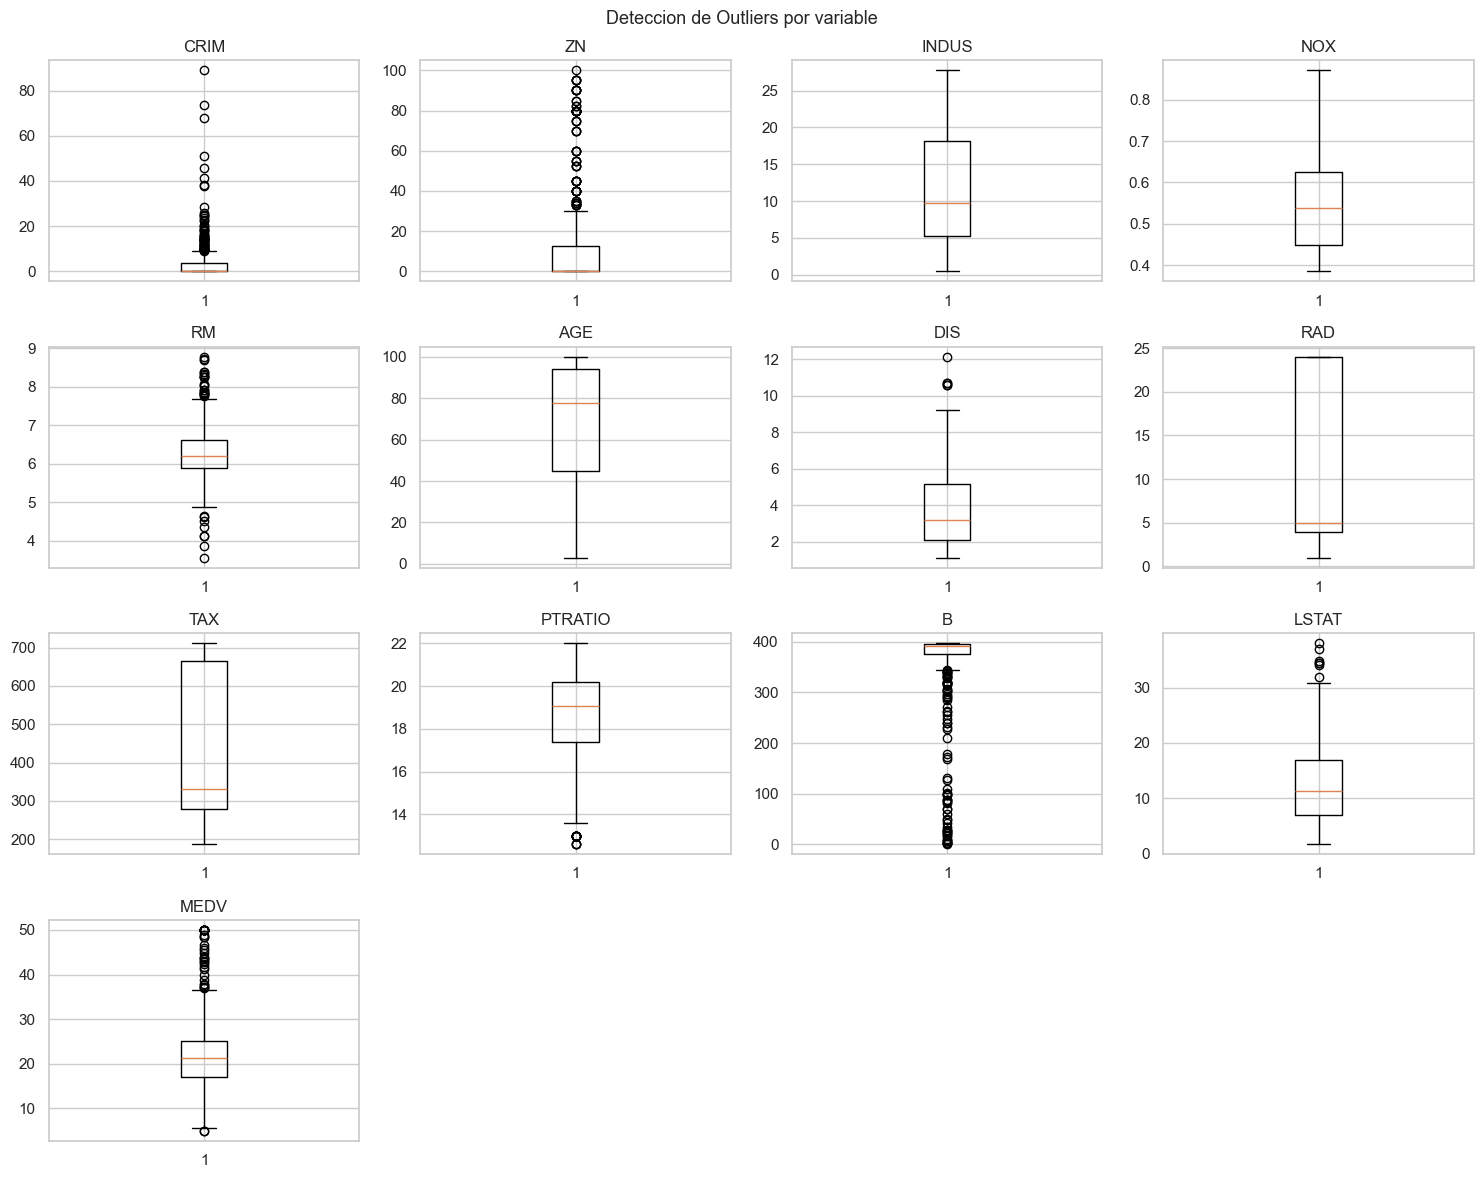

In [6]:
cols = [c for c in df.columns if c != 'CHAS']

fig, axes = plt.subplots(4, 4, figsize=(15, 12))
axes_flat = axes.flatten()

for i, col in enumerate(cols):
    axes_flat[i].boxplot(df[col])
    axes_flat[i].set_title(col)

for j in range(len(cols), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle("Deteccion de Outliers por variable", fontsize=13)
plt.tight_layout()
plt.show()

In [7]:
IQR_FACTOR = params['cleaning']['iqr_factor']

cols_analizar = [c for c in df.columns if c not in ('CHAS', 'MEDV')]

reporte = {}

for col in cols_analizar:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - IQR_FACTOR * IQR
    upper = Q3 + IQR_FACTOR * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    
    if n_outliers > 0:
        reporte[col] = {
            'outliers': n_outliers,
            'porcentaje': round(100 * n_outliers / len(df), 2),
            'limite_inferior': round(lower, 3),
            'limite_superior': round(upper, 3)
        }

pd.DataFrame(reporte).T

,outliers,porcentaje,limite_inferior,limite_superior
CRIM,66.0,13.04,-5.311,9.070
ZN,68.0,13.44,-18.750,31.250
RM,30.0,5.93,4.778,7.731
DIS,5.0,0.99,-2.532,9.821
PTRATIO,15.0,2.96,13.200,24.400
B,77.0,15.22,344.106,427.496
LSTAT,7.0,1.38,-8.058,31.963


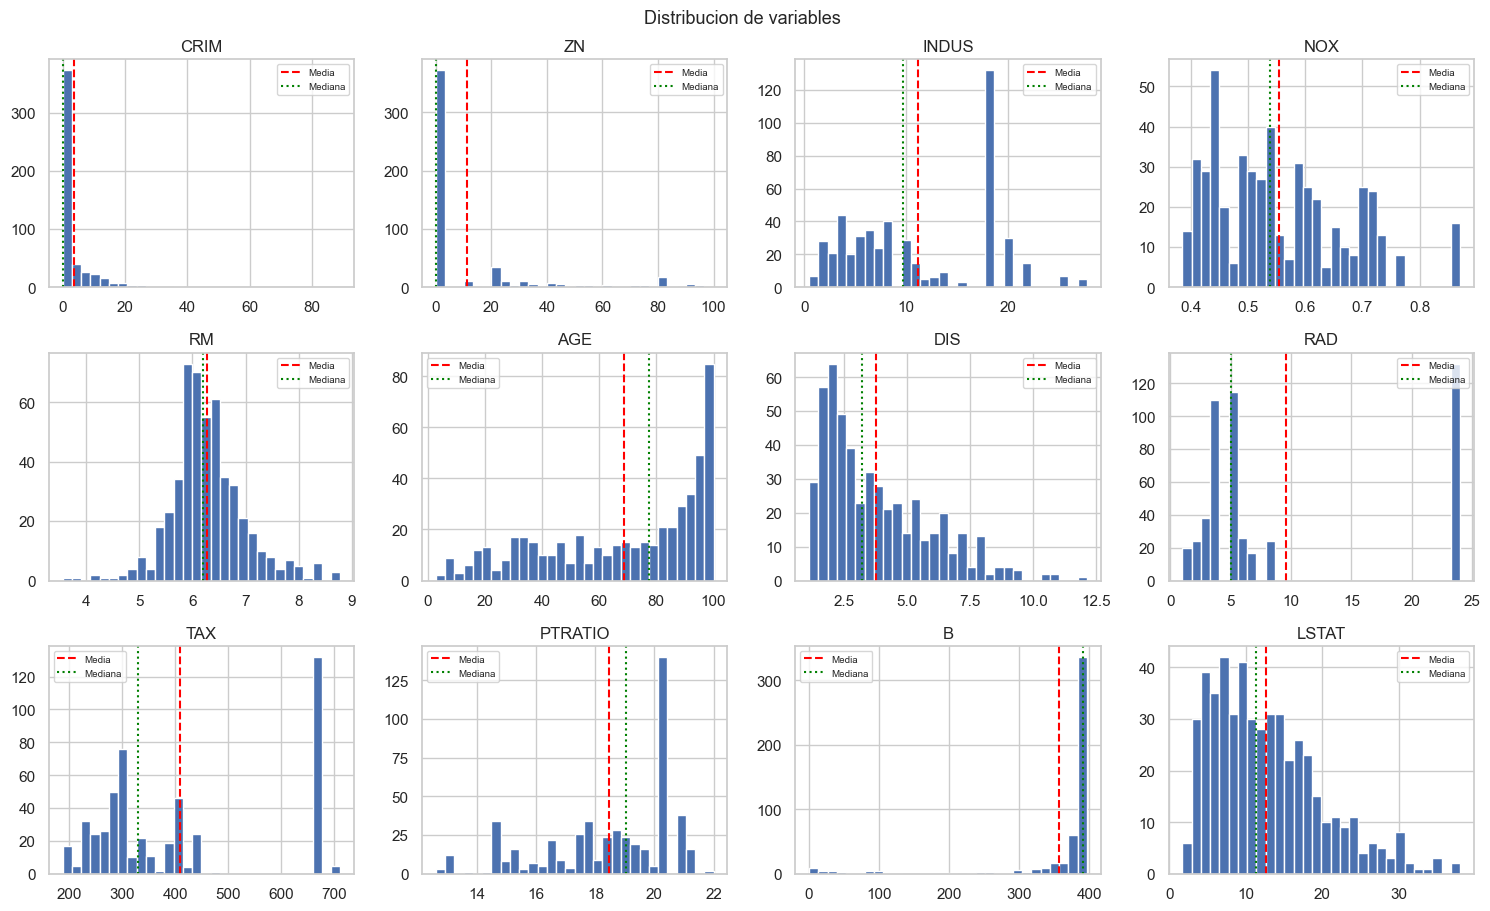

In [8]:
fig, axes = plt.subplots(4, 4, figsize=(15, 12))
axes_flat = axes.flatten()

for i, col in enumerate(cols_analizar):
    axes_flat[i].hist(df[col], bins=30, edgecolor='white')
    axes_flat[i].set_title(col)
    axes_flat[i].axvline(df[col].mean(), color='red', linestyle='--', label='Media')
    axes_flat[i].axvline(df[col].median(), color='green', linestyle=':', label='Mediana')
    axes_flat[i].legend(fontsize=7)

for j in range(len(cols_analizar), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle("Distribucion de variables", fontsize=13)
plt.tight_layout()
plt.show()